# Assignment 1 — Supervised ML Benchmark
### Telecom Customer Churn Classification

This notebook walks through the full experiment: data inspection, preprocessing,
training seven classification models, evaluating them, and running the required
comparison experiments. All heavy-lifting functions live in `src/` and are simply
called from here so the logic is reusable and testable outside the notebook.


In [1]:
import sys, os
sys.path.insert(0, os.path.abspath('../src'))
import warnings; warnings.filterwarnings('ignore')

import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import Image, display

from data_prep import load_and_inspect, split_data, build_preprocessor
from utils import evaluate_split, fit_and_time, plot_confusion_matrix


## 1. Data inspection & cleaning

In [2]:
df = load_and_inspect('../data/telecom_churn.csv')
df.head()

DATA INSPECTION
Shape: (6025, 15)

Dtypes:
customer_id              str
tenure_months          int64
monthly_charges      float64
total_charges        float64
age                  float64
num_support_calls      int64
contract_type            str
internet_service         str
payment_method           str
tech_support             str
paperless_billing        str
has_partner              str
has_dependents           str
senior_citizen         int64
churn                  int64
dtype: object

Target distribution:
churn
0    0.673029
1    0.326971
Name: proportion, dtype: float64

Null counts:
total_charges    121
age               91
tech_support      60
dtype: int64

Duplicate rows (full row match): 25

Dropped 25 duplicate rows. Dropped identifier column 'customer_id'.
Final shape after cleaning: (6000, 14)


,tenure_months,monthly_charges,total_charges,age,num_support_calls,contract_type,internet_service,payment_method,tech_support,paperless_billing,has_partner,has_dependents,senior_citizen,churn
0,61,66.22,3998.84,60.0,2,One year,No,Electronic check,No internet service,Yes,No,No,1,0
1,47,48.70,2277.40,66.0,1,One year,Fiber optic,Bank transfer,Yes,No,Yes,No,1,1
2,56,36.14,2010.97,61.0,1,Two year,Fiber optic,Electronic check,No,No,No,No,1,0
3,27,105.35,2912.18,67.0,3,Month-to-month,No,Credit card,No,Yes,No,No,0,1
4,9,47.66,433.19,22.0,2,Month-to-month,No,Mailed check,No,Yes,Yes,Yes,0,0


## 2. Train / validation / test split

In [3]:
X_train, X_val, X_test, y_train, y_val, y_test = split_data(df)

Train: 3600 rows | Val: 1200 rows | Test: 1200 rows
Train churn rate: 0.326 | Val: 0.327 | Test: 0.327


## 3. Train all seven required models

See `src/train.py` for the full script version (this reproduces the same logic).

In [4]:
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.svm import SVC
from xgboost import XGBClassifier

models = {
    'Logistic Regression': LogisticRegression(max_iter=1000, random_state=42),
    'KNN (k=5)': KNeighborsClassifier(n_neighbors=5),
    'Decision Tree': DecisionTreeClassifier(max_depth=6, random_state=42),
    'Random Forest': RandomForestClassifier(n_estimators=300, max_depth=10, random_state=42, n_jobs=-1),
    'Gradient Boosting': GradientBoostingClassifier(random_state=42),
    'XGBoost': XGBClassifier(eval_metric='logloss', random_state=42, n_jobs=-1, verbosity=0),
    'SVM': SVC(probability=True, kernel='rbf', random_state=42),
}

results = []
for name, model in models.items():
    pre = build_preprocessor(scale_numeric=True)
    pipe = Pipeline([('preprocessor', pre), ('model', model)])
    pipe, train_time = fit_and_time(pipe, X_train, y_train)
    m, preds, proba = evaluate_split(pipe, X_test, y_test, 'test')
    m['model'] = name
    m['train_time_s'] = train_time
    results.append(m)

results_df = pd.DataFrame(results)[['model','accuracy','precision','recall','f1','roc_auc','train_time_s','inference_ms_per_sample']]
results_df.sort_values('f1', ascending=False)

,model,accuracy,precision,recall,f1,roc_auc,train_time_s,inference_ms_per_sample
0,Logistic Regression,0.706667,0.577519,0.380102,0.458462,0.741709,0.048275,0.006157
1,KNN (k=5),0.663333,0.481250,0.392857,0.432584,0.622152,0.020033,0.045844
6,SVM,0.702500,0.576419,0.336735,0.425121,0.716010,2.474349,0.143544
4,Gradient Boosting,0.691667,0.544355,0.344388,0.421875,0.726305,0.642991,0.007708
5,XGBoost,0.660833,0.475570,0.372449,0.417740,0.688457,0.132052,0.009208
3,Random Forest,0.692500,0.548936,0.329082,0.411483,0.726116,1.420774,0.048380
2,Decision Tree,0.684167,0.532020,0.275510,0.363025,0.722698,0.040716,0.006373


## 4. Results table (already generated by `src/train.py`)

In [5]:
summary = pd.read_csv('../results/test_summary_ranked.csv')
summary

,model,accuracy,precision,recall,f1,roc_auc,train_time_s,inference_ms_per_sample
0,Logistic Regression,0.706667,0.577519,0.380102,0.458462,0.741709,0.032843,0.006794
1,KNN (k=5),0.663333,0.481250,0.392857,0.432584,0.622152,0.020038,0.023929
2,SVM,0.702500,0.576419,0.336735,0.425121,0.716010,2.300267,0.136830
3,Gradient Boosting,0.691667,0.544355,0.344388,0.421875,0.726305,0.597331,0.007819
4,XGBoost,0.660833,0.475570,0.372449,0.417740,0.688457,0.108988,0.007590
5,Random Forest,0.692500,0.548936,0.329082,0.411483,0.726116,1.280148,0.044554
6,Decision Tree,0.684167,0.532020,0.275510,0.363025,0.722698,0.031139,0.006010


## 5. Confusion matrices (test set)

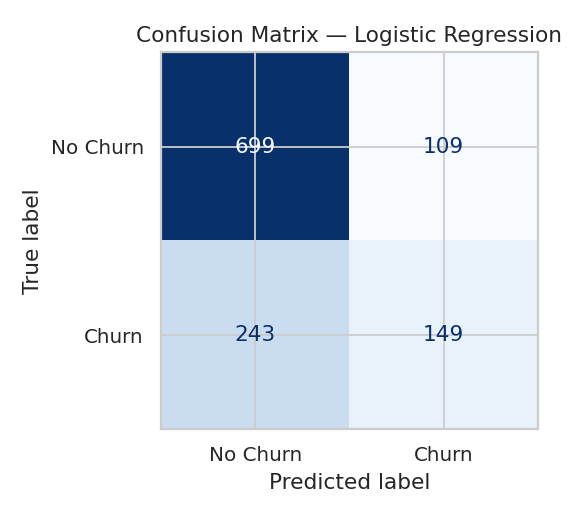

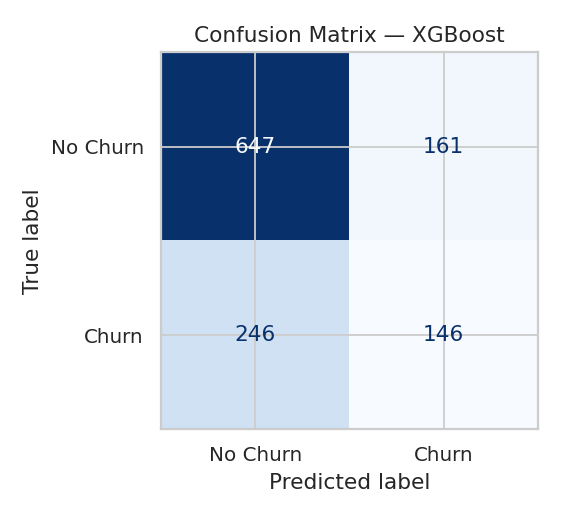

In [6]:
display(Image('../results/confusion_matrices/Logistic_Regression.png'))
display(Image('../results/confusion_matrices/XGBoost.png'))

## 6. ROC curves (test set)

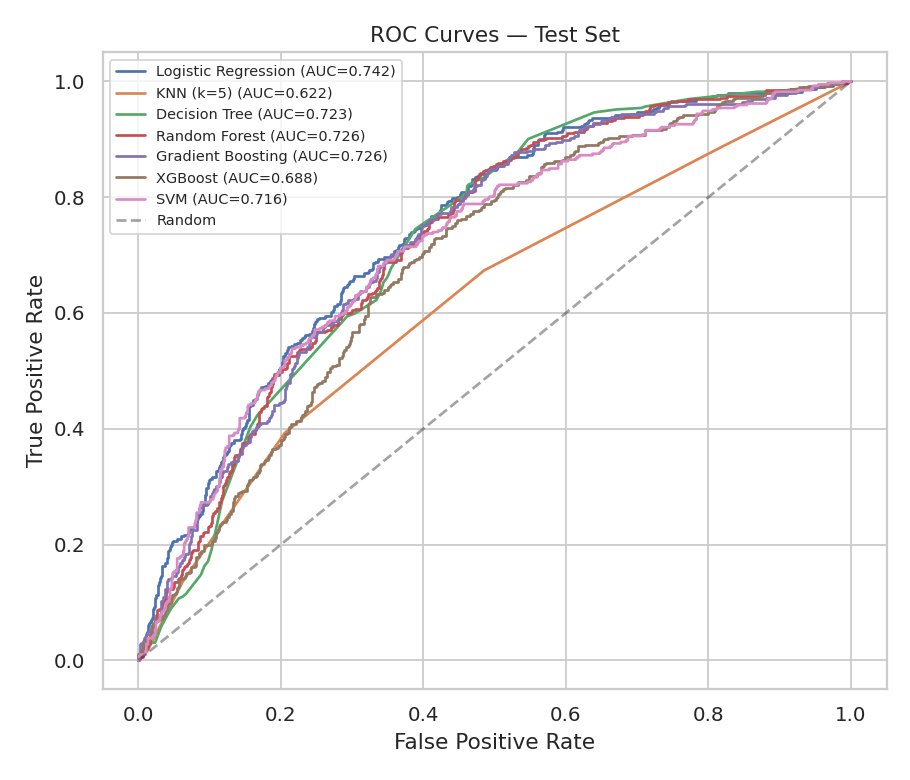

In [7]:
display(Image('../results/roc_curves_test.png'))

## 7. Training & inference timing comparison

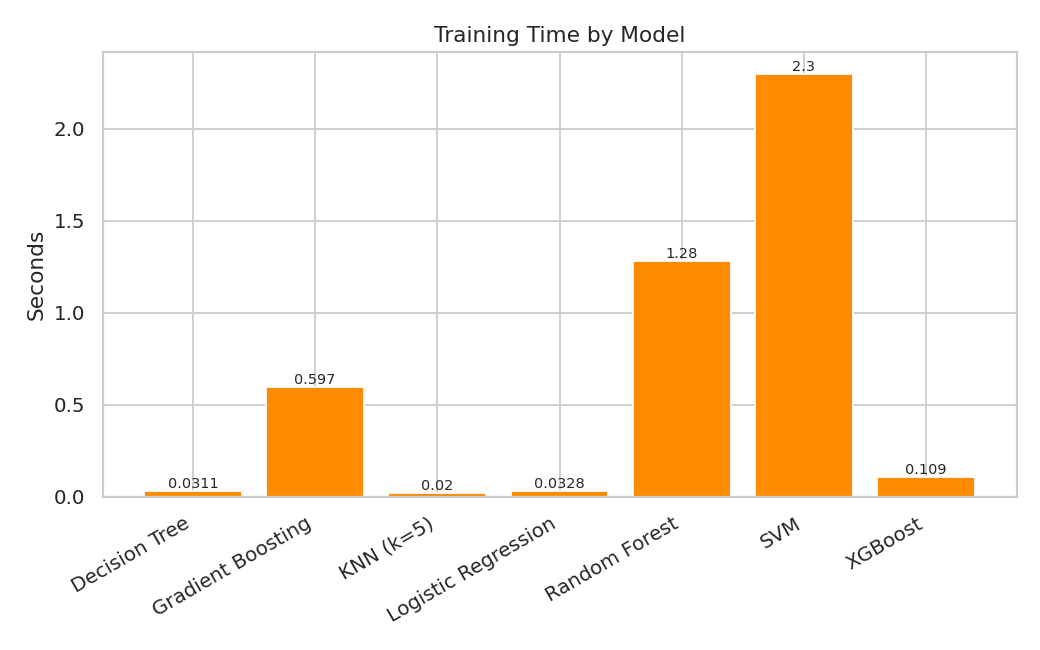

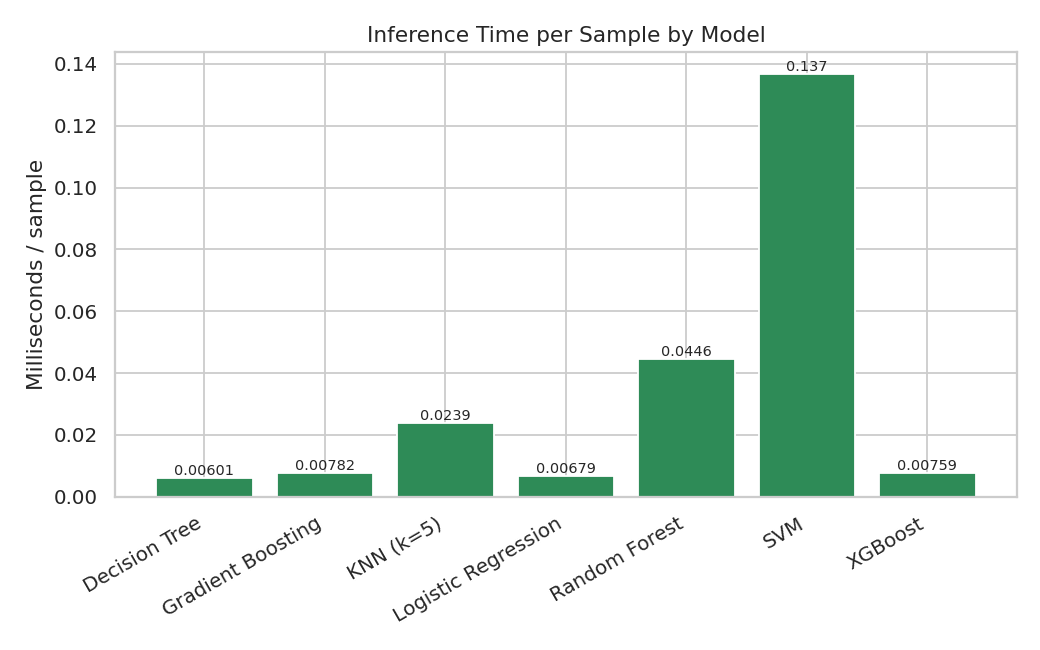

In [8]:
display(Image('../results/training_time_comparison.png'))
display(Image('../results/inference_time_comparison.png'))

## 8. Required experiments

Full logic lives in `src/experiments.py`. Key outputs are loaded below.

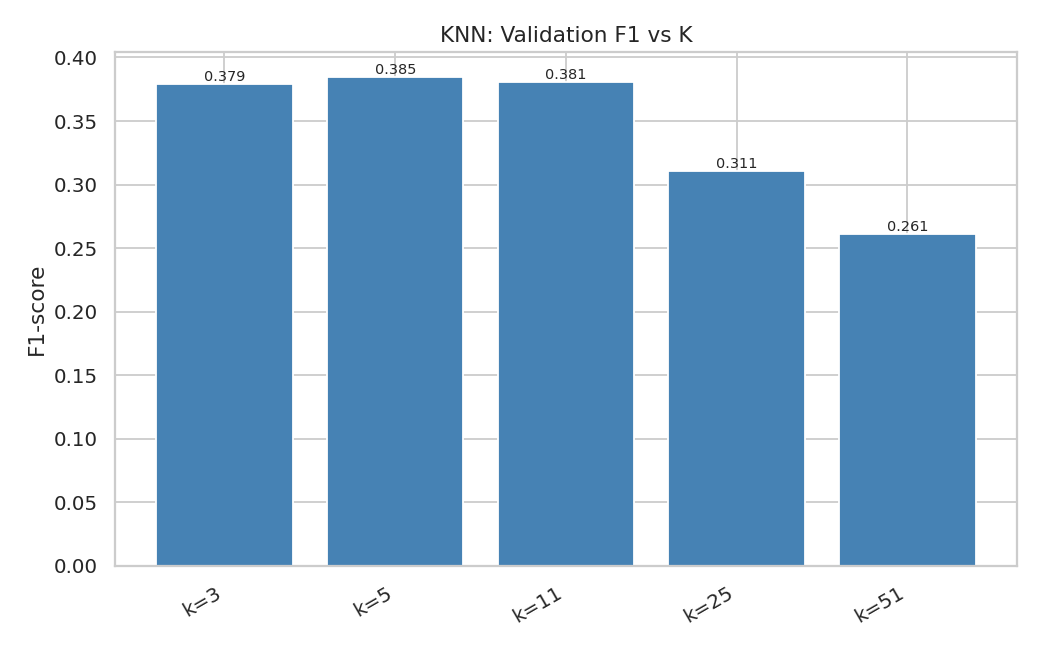

,k,train_f1,val_f1,val_accuracy
0,3,0.686878,0.379310,0.640000
1,5,0.610169,0.384728,0.650833
2,11,0.498187,0.380645,0.680000
3,25,0.406542,0.310714,0.678333
4,51,0.288512,0.261209,0.684167


In [9]:
display(Image('../results/experiment_plots/knn_k_comparison.png'))
pd.read_csv('../results/experiment_plots/knn_k_comparison.csv')

In [10]:
pd.read_csv('../results/experiment_plots/decision_tree_depth_comparison.csv')

,tree,train_f1,val_f1,train_accuracy,val_accuracy,gap_accuracy
0,shallow (depth=2),0.470186,0.521490,0.698889,0.721667,-0.022778
1,moderate (depth=6),0.435239,0.369231,0.731111,0.692500,0.038611
2,deep (depth=None),1.000000,0.435544,1.000000,0.624167,0.375833


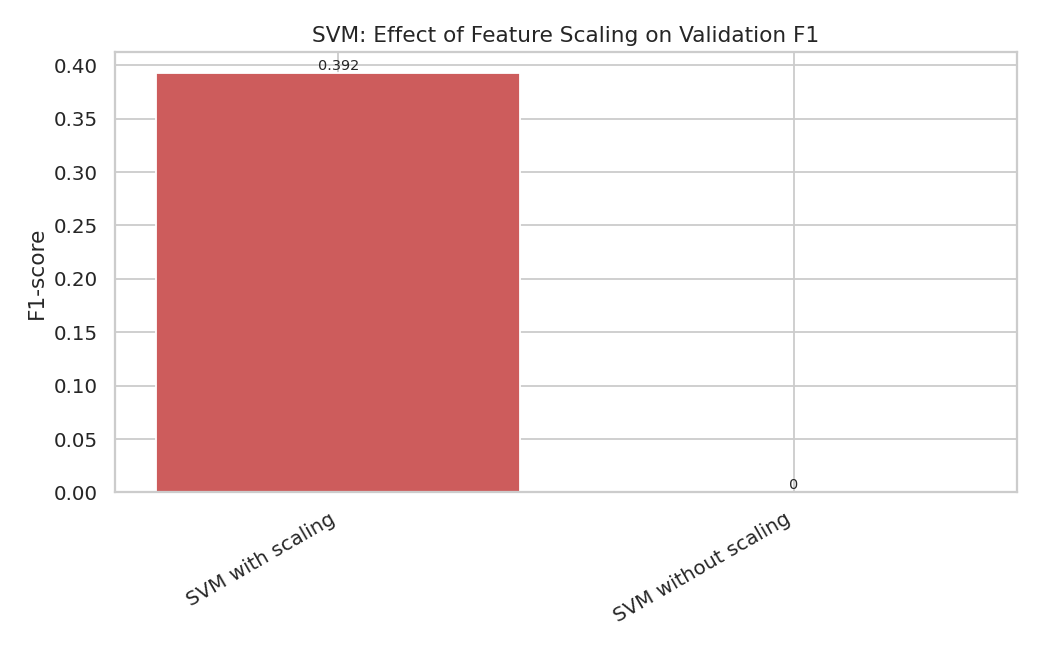

,setup,val_f1,val_accuracy,val_roc_auc
0,SVM with scaling,0.392491,0.703333,0.716521
1,SVM without scaling,0.000000,0.673333,0.513197


In [11]:
display(Image('../results/experiment_plots/svm_scaling_comparison.png'))
pd.read_csv('../results/experiment_plots/svm_scaling_comparison.csv')

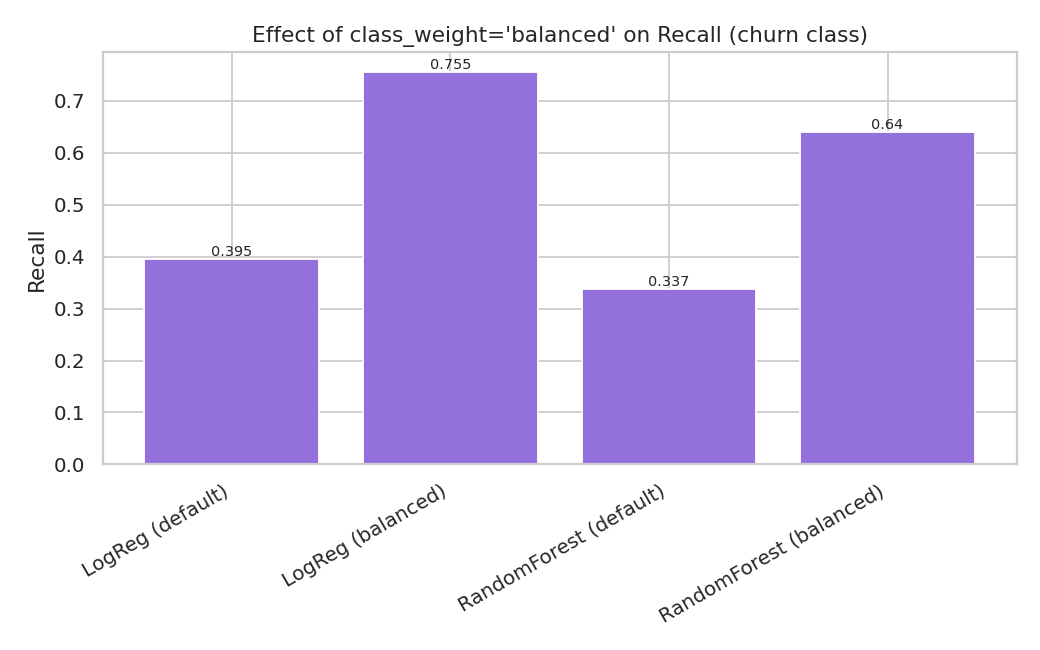

,setup,val_precision,val_recall,val_f1,val_accuracy
0,LogReg (default),0.607843,0.395408,0.479134,0.719167
1,LogReg (balanced),0.495812,0.755102,0.598584,0.669167
2,RandomForest (default),0.576419,0.336735,0.425121,0.702500
3,RandomForest (balanced),0.525105,0.640306,0.577011,0.693333


In [12]:
display(Image('../results/experiment_plots/class_imbalance_recall.png'))
pd.read_csv('../results/experiment_plots/class_imbalance_comparison.csv')

## 9. Conclusions

See `observations.md` at the project root for the full written analysis and
model-selection reasoning.